# CREDIT GUARD(AI-powered credit card risk analysis system)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
colors = sb.color_palette("crest", 2)


C:\Users\Asus\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
a = pd.read_csv("../Datasets/Applications_cc.csv")

In [3]:
a

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [4]:
b = pd.read_csv("../Datasets/credit_record _cc.csv")

In [5]:
b

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


In [6]:
common=a[a["ID"].isin(b["ID"])]

In [7]:
common

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434808,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0
434809,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0
434810,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0
434811,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0


* **Cleaning Duplicate values in Dataset**

In [8]:
a_cleaned= a.drop_duplicates(subset=['ID'],keep='first')
b_cleaned=b.drop_duplicates(subset=['ID'],keep='first')


In [9]:
a_cleaned

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [10]:
b_cleaned

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
4,5001712,0,C
23,5001713,0,X
45,5001714,0,X
60,5001715,0,X
...,...,...,...
1048494,5150482,-11,C
1048512,5150483,0,X
1048530,5150484,0,C
1048543,5150485,0,0


* **Merging both the dataset for performing EDA**

In [11]:
df=pd.merge(a_cleaned,b_cleaned,on='ID',how='inner')

In [12]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0,C
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,-22,X
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,0,5
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0,C
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0,C
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,0,2


*  **Cleaning the dataset**

In [13]:
df.isnull().sum()

ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_MOBIL                 0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
OCCUPATION_TYPE        11323
CNT_FAM_MEMBERS            0
MONTHS_BALANCE             0
STATUS                     0
dtype: int64

In [14]:
df.NAME_EDUCATION_TYPE.unique()

<ArrowStringArray>
[             'Higher education', 'Secondary / secondary special',
             'Incomplete higher',               'Lower secondary',
               'Academic degree']
Length: 5, dtype: str

In [15]:
df.NAME_EDUCATION_TYPE=df.NAME_EDUCATION_TYPE.replace("Secondary / secondary special","Secondary special")

In [16]:
df.NAME_FAMILY_STATUS.unique()

<ArrowStringArray>
['Civil marriage', 'Married', 'Single / not married', 'Separated', 'Widow']
Length: 5, dtype: str

In [17]:
df.NAME_FAMILY_STATUS=df.NAME_FAMILY_STATUS.replace("Single / not married","Single")

In [18]:
df.NAME_HOUSING_TYPE.unique()

<ArrowStringArray>
[   'Rented apartment',   'House / apartment', 'Municipal apartment',
        'With parents',     'Co-op apartment',    'Office apartment']
Length: 6, dtype: str

In [19]:
df.NAME_HOUSING_TYPE=df.NAME_HOUSING_TYPE.replace("House / apartment","House")

In [20]:
df.OCCUPATION_TYPE = df.OCCUPATION_TYPE.fillna("Unknown")

In [21]:
df.OCCUPATION_TYPE.unique()

<ArrowStringArray>
[              'Unknown',        'Security staff',           'Sales staff',
           'Accountants',              'Laborers',              'Managers',
               'Drivers',            'Core staff', 'High skill tech staff',
        'Cleaning staff', 'Private service staff',         'Cooking staff',
    'Low-skill Laborers',        'Medicine staff',           'Secretaries',
  'Waiters/barmen staff',              'HR staff',         'Realty agents',
              'IT staff']
Length: 19, dtype: str

In [22]:
df.OCCUPATION_TYPE=df.OCCUPATION_TYPE.replace("Waiters/barmen staff","Waiters")

In [23]:
df.STATUS.unique()

<ArrowStringArray>
['C', '0', 'X', '1', '5', '3', '4', '2']
Length: 8, dtype: str

In [24]:
status_map = {
    '0': 0,
    '1': 1,
    '2': 1,
    '3': 1,
    '4': 1,
    '5': 1,
    'C': 0,
    'X': 0
}
df['CREDIT_RISK'] = df.STATUS.map(status_map)


In [25]:
df.CREDIT_RISK.value_counts()

CREDIT_RISK
0    36075
1      382
Name: count, dtype: int64

In [26]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,CREDIT_RISK
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,0,C,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,0,C,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary special,Married,House,...,-1134,1,0,0,0,Security staff,2.0,0,C,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary special,Single,House,...,-3051,1,0,1,1,Sales staff,1.0,0,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary special,Single,House,...,-3051,1,0,1,1,Sales staff,1.0,-22,X,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary special,Married,House,...,-2420,1,0,0,0,Managers,2.0,0,5,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House,...,-1325,1,0,1,1,Medicine staff,2.0,0,C,0
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House,...,-1325,1,0,1,1,Medicine staff,2.0,0,C,0
36455,5150049,F,N,Y,0,283500.0,Working,Secondary special,Married,House,...,-655,1,0,0,0,Sales staff,2.0,0,2,1


*  **Identifying what dataset is having by using shape,columns and data types**

In [27]:
print("Shape:", df.shape)
print(df.columns)
print(df.dtypes)

Shape: (36457, 21)
Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE',
       'STATUS', 'CREDIT_RISK'],
      dtype='str')
ID                       int64
CODE_GENDER                str
FLAG_OWN_CAR               str
FLAG_OWN_REALTY            str
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE           str
NAME_EDUCATION_TYPE        str
NAME_FAMILY_STATUS         str
NAME_HOUSING_TYPE          str
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE            str
CNT_FAM_MEMBERS        float64
MONTHS_BAL

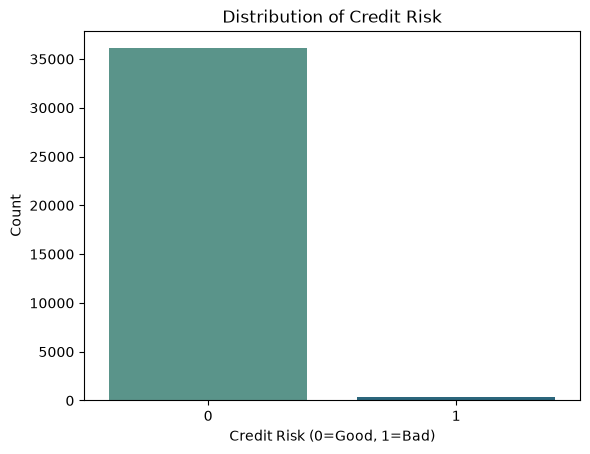

CREDIT_RISK
0    36075
1      382
Name: count, dtype: int64


In [28]:
import warnings
warnings.filterwarnings('ignore')
sb.countplot( x=df.CREDIT_RISK,palette='crest')
plt.title("Distribution of Credit Risk")
plt.xlabel("Credit Risk (0=Good, 1=Bad)")
plt.ylabel("Count")
plt.show()
print(df.CREDIT_RISK.value_counts())

* The **CREDIT_RISK distribution** is highly imbalanced, with **36,351 customers (99.71%)** classified as **Good Credit (0)** and only **106 customers** (0.29%) classified as **Bad Credit (1)**.

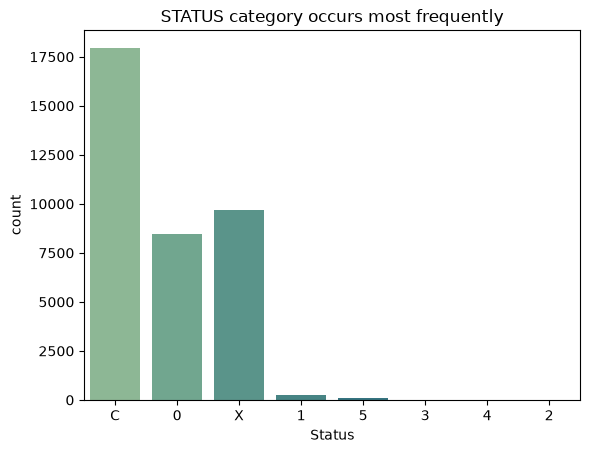

STATUS
C    17950
X     9669
0     8456
1      276
5       76
2       19
3        6
4        5
Name: count, dtype: int64


In [29]:
import warnings
warnings.filterwarnings('ignore')
sb.countplot(x=df.STATUS,palette='crest')
plt.title("STATUS category occurs most frequently")
plt.xlabel("Status")
plt.ylabel("count")
plt.show()
print(df.STATUS.value_counts())

* The majority of customers have **closed loans (C)**, **no loan activity (X)**, or have **paid on time (0)**, indicating a generally good repayment history. 
* **Late payment** and **default statuses (1–5)** are very rare, suggesting that only a small proportion of customers exhibit credit risk.

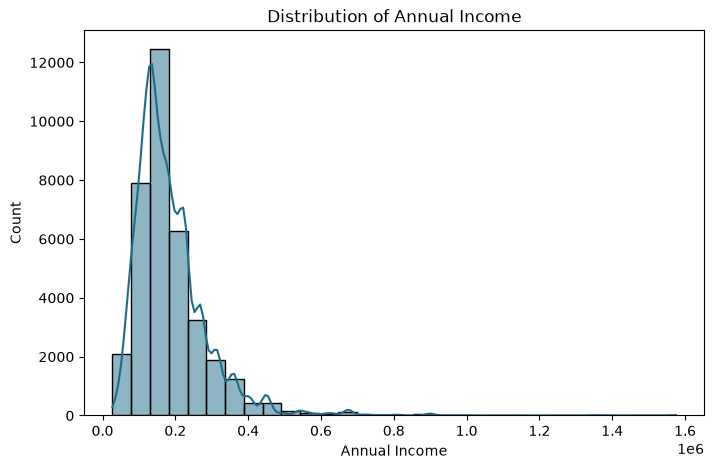

In [30]:
plt.figure(figsize=(8,5))
sb.histplot(x=df.AMT_INCOME_TOTAL, bins=30, kde=True,color=colors[1])
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.show()

* The **annual income distribution** is **right-skewed**, with most customers earning between **100,000 and 250,000**.
* A few customers have very high incomes, creating a **long right tail** and indicating the presence of **high-income outliers**.

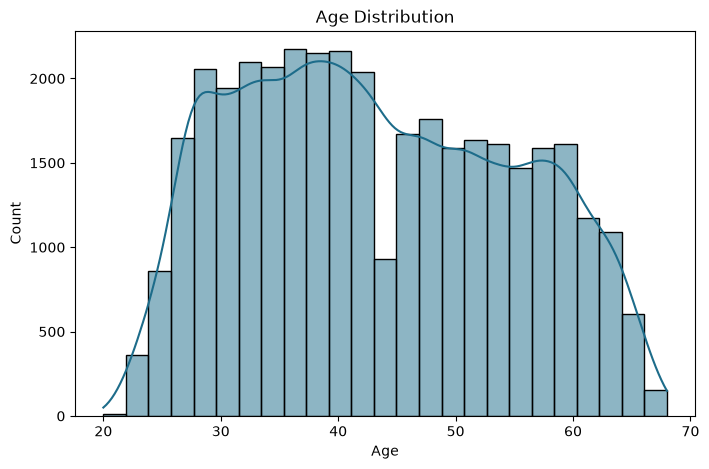

In [31]:
df['AGE'] =(-df["DAYS_BIRTH"] // 365)
plt.figure(figsize=(8,5))
sb.histplot(x=df.AGE,bins=25,kde=True,color=colors[1])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

* The age distribution shows that most customers are between **30 and 60 years old**, with the highest concentration around **35–40 years**. 
* The dataset contains relatively **fewer young (below 25)** and **older (above 65)** customers.

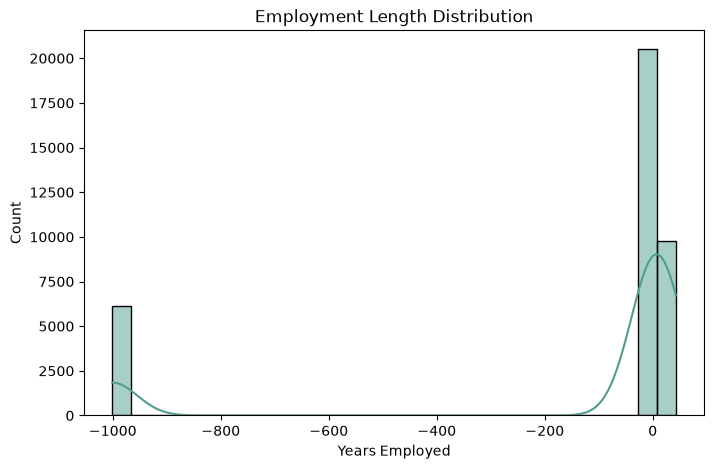

In [32]:
df['EMPLOYMENT_YEARS']=(-df["DAYS_EMPLOYED"] / 365)
plt.figure(figsize=(8,5))
sb.histplot(x=df.EMPLOYMENT_YEARS,bins=30,kde=True,color=colors[0])
plt.title("Employment Length Distribution")
plt.xlabel("Years Employed")
plt.show()

* The employment length distribution is concentrated between **0 and 40 years**, with most customers having **relatively shorter employment durations**. 
* The large spike at **-1001 years** represents the placeholder value (DAYS_EMPLOYED = 365243) **used for pensioners** or customers who are not currently employed, rather than actual employment length.

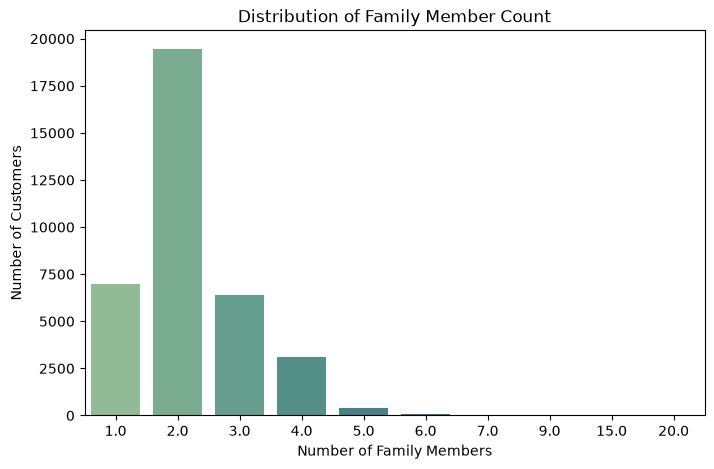

CNT_FAM_MEMBERS
2.0     19463
1.0      6987
3.0      6421
4.0      3106
5.0       397
6.0        58
7.0        19
15.0        3
9.0         2
20.0        1
Name: count, dtype: int64


In [33]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(8,5))
sb.countplot(x=df.CNT_FAM_MEMBERS,order=df.CNT_FAM_MEMBERS.value_counts().sort_index().index,palette='crest')
plt.title("Distribution of Family Member Count")
plt.xlabel("Number of Family Members")
plt.ylabel("Number of Customers")
plt.show()
print(df.CNT_FAM_MEMBERS.value_counts())

* The majority of customers have **2 family members**, followed by 1 and 3 family members, indicating that small families are the **most common** in the dataset. 
* Customers with **more than 5 family members** are very rare, making larger families uncommon.

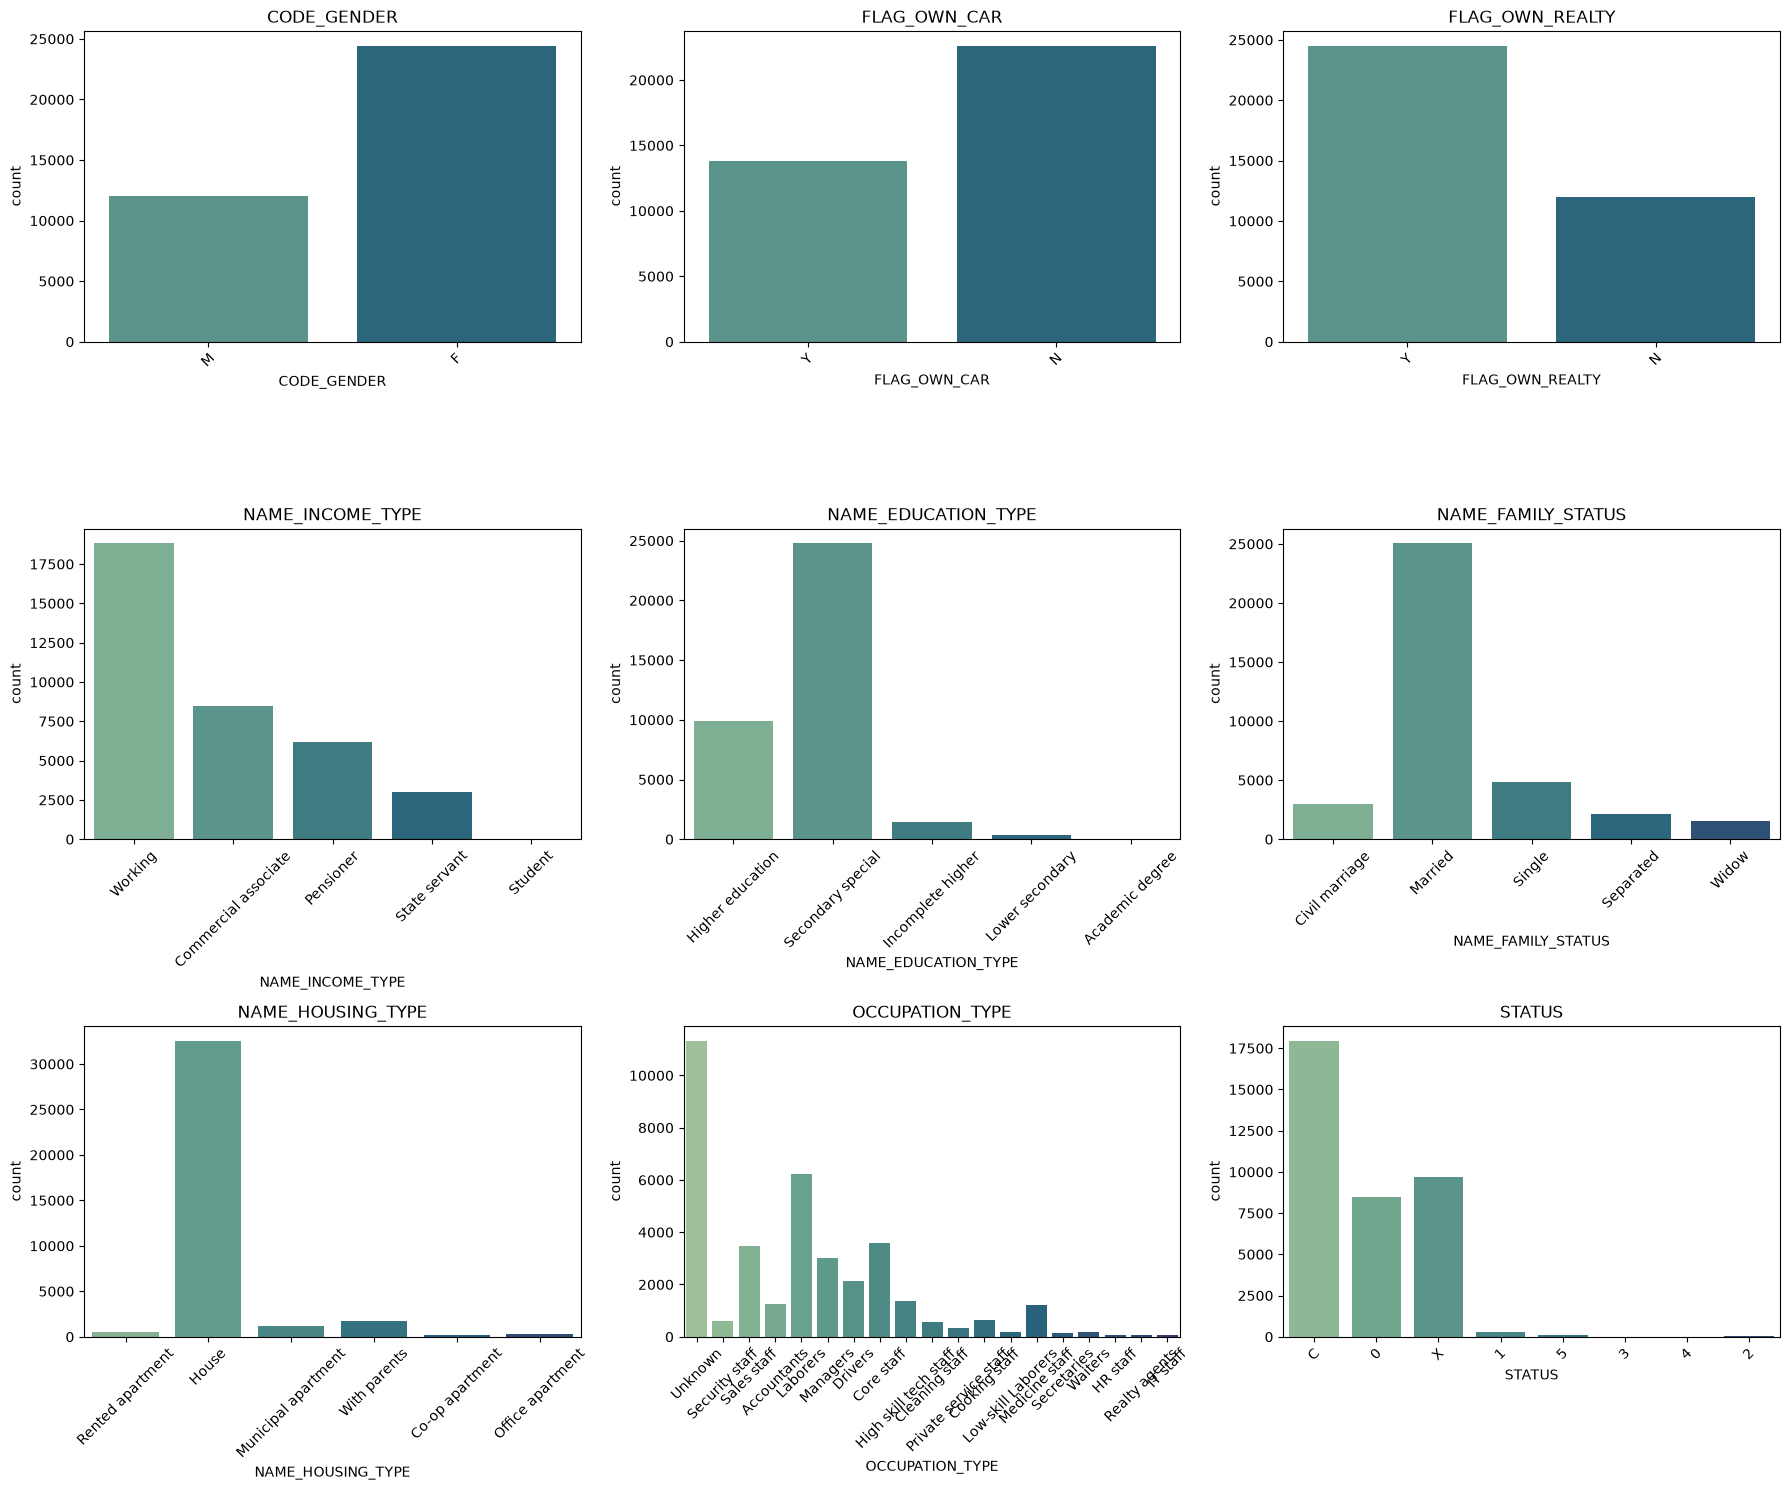

In [34]:
import warnings
warnings.filterwarnings('ignore')
categorical_cols = [
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'STATUS'
]
plt.figure(figsize=(18, 15))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)  
    sb.countplot(data=df, x=col,palette='crest')
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

* **Most customers are female, do not own a car, but own a house/property. The majority are working, have secondary education, are married, and live in their own house, while loan closed (C), no loan activity (X), and paid on time (0) are the most common credit statuses**.

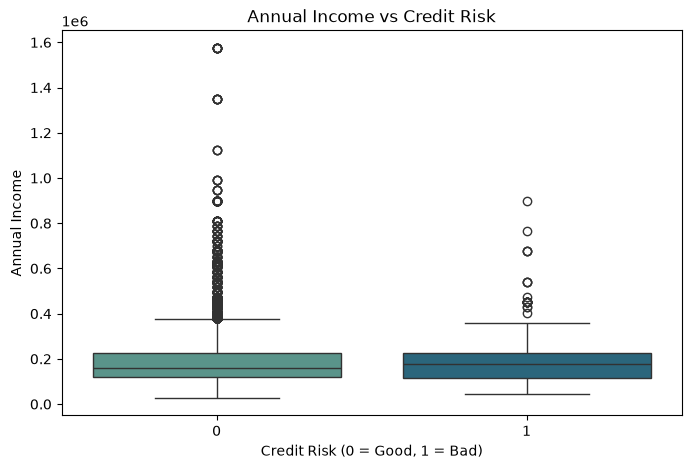

In [35]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(8,5))
sb.boxplot( x=df.CREDIT_RISK, y=df.AMT_INCOME_TOTAL,palette='crest')
plt.title("Annual Income vs Credit Risk")
plt.xlabel("Credit Risk (0 = Good, 1 = Bad)")
plt.ylabel("Annual Income")
plt.show()

* Customers with **good credit (0)** and **bad credit (1)** have similar **median annual incomes**, although the **bad credit group** has a **slightly higher median**. The **good credit group** contains **many more high-income outliers**, **indicating greater variability** in annual income.

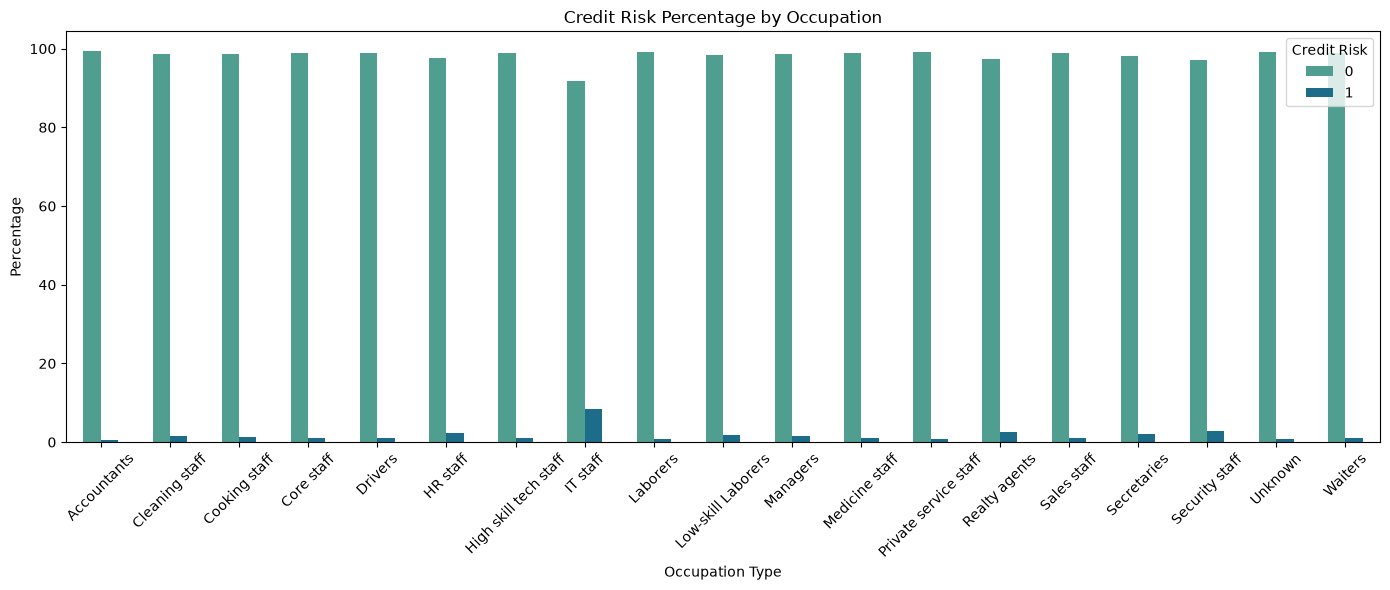

CREDIT_RISK,0,1
OCCUPATION_TYPE,,
Accountants,99.435939,0.564061
Cleaning staff,98.548094,1.451906
Cooking staff,98.625954,1.374046
Core staff,98.941799,1.058201
Drivers,98.924228,1.075772
HR staff,97.647059,2.352941
High skill tech staff,98.987708,1.012292
IT staff,91.666667,8.333333
Laborers,99.162776,0.837224


In [36]:
occupation_risk = pd.crosstab(df.OCCUPATION_TYPE,df.CREDIT_RISK,normalize='index') * 100
occupation_risk.plot(kind='bar',figsize=(14,6),color=colors)
plt.title("Credit Risk Percentage by Occupation")
plt.xlabel("Occupation Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Credit Risk")
plt.tight_layout()
plt.show()
occupation_risk

* Most occupation types have a **very high proportion of good credit customers (over 98%)**, indicating generally low credit risk across occupations. **Secretaries (1.32%), Low-skill Laborers (1.14%), and Security staff (1.01%) have the highest percentages of bad credit customers**, although the overall bad credit rate remains low.

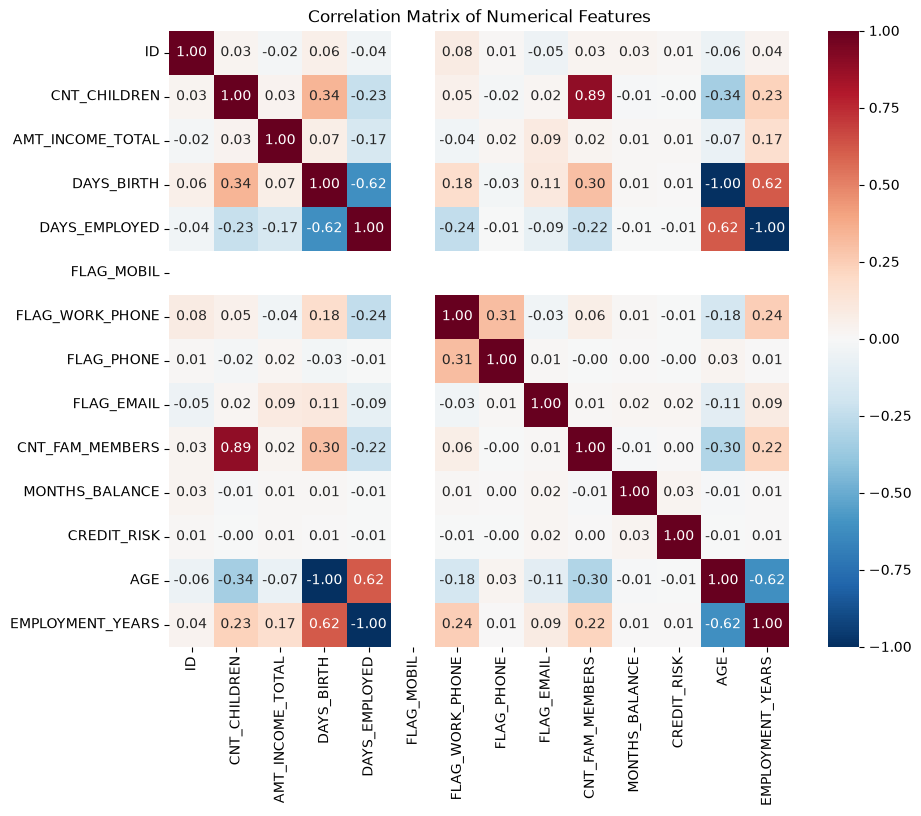

In [37]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
correlation = numerical_cols.corr()
plt.figure(figsize=(10, 8))
sb.heatmap(correlation,annot=True,cmap='RdBu_r',fmt='.2f')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

* **Most numerical features show weak correlations**, indicating limited linear relationships between them.
* The **strongest positive correlation** is between **CNT_CHILDREN and CNT_FAM_MEMBERS (0.89)**, while **AGE and EMPLOYMENT_YEARS (0.62) are positively correlated**, and **AGE and DAYS_BIRTH (-1.00) exhibit a perfect negative correlation** because age is derived directly from DAYS_BIRTH.

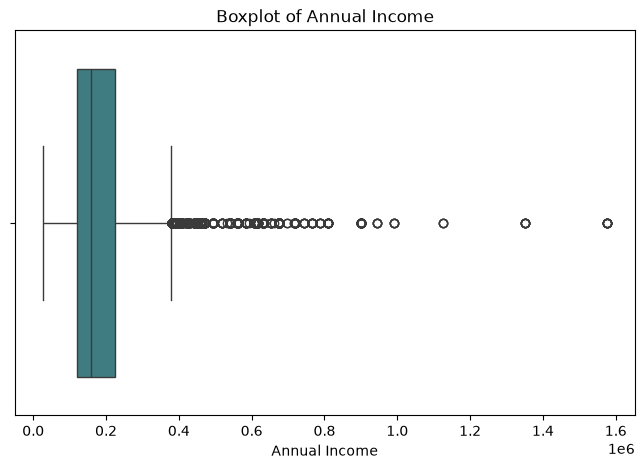

In [38]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(8,5))
sb.boxplot(x=df.AMT_INCOME_TOTAL,palette='crest')
plt.title("Boxplot of Annual Income")
plt.xlabel("Annual Income")
plt.show()

* The boxplot indicates the presence of several extreme high-income outliers, with a **few customers earning significantly more than the majority**. **Most customers have annual incomes within a relatively narrow range**, while only a small number fall far beyond the upper whisker.

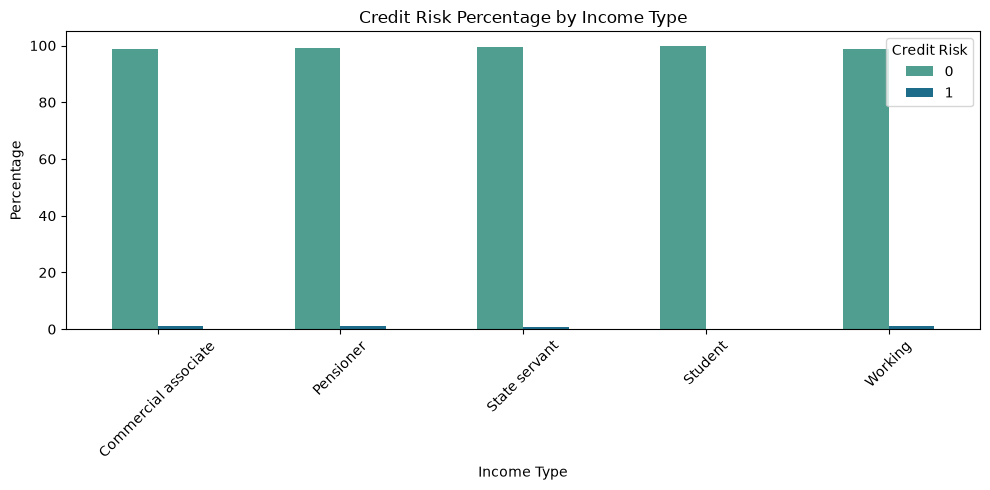

CREDIT_RISK                    0         1
NAME_INCOME_TYPE                          
Commercial associate   98.786808  1.213192
Pensioner              99.008453  0.991547
State servant          99.363484  0.636516
Student               100.000000  0.000000
Working                98.942558  1.057442


In [39]:
income_risk = pd.crosstab(df.NAME_INCOME_TYPE,df.CREDIT_RISK,normalize='index') * 100
income_risk.plot(kind='bar',figsize=(10,5),color=colors)
plt.title("Credit Risk Percentage by Income Type")
plt.xlabel("Income Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title='Credit Risk')
plt.tight_layout()
plt.show()
print(income_risk)

* All income types have an extremely high proportion of good credit customers (above 99%), indicating a very low overall default rate.
* **Commercial associates (0.35%) and Pensioners (0.34%) have slightly higher bad credit rates**, while Students and State servants exhibit the lowest credit risk.

# Machinne Learning Model Selection

In [40]:
df.corr(numeric_only=True)

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,MONTHS_BALANCE,CREDIT_RISK,AGE,EMPLOYMENT_YEARS
ID,1.000000,0.028878,-0.017667,0.056016,-0.038043,NaN,0.079215,0.009879,-0.046979,0.026624,0.025194,0.009000,-0.056036,0.038043
CNT_CHILDREN,0.028878,1.000000,0.033691,0.339357,-0.229379,NaN,0.048091,-0.016291,0.015960,0.889114,-0.011469,-0.000501,-0.339240,0.229379
AMT_INCOME_TOTAL,-0.017667,0.033691,1.000000,0.067908,-0.168611,NaN,-0.037746,0.017245,0.086681,0.023750,0.008727,0.009730,-0.067715,0.168611
DAYS_BIRTH,0.056016,0.339357,0.067908,1.000000,-0.616213,NaN,0.179054,-0.028659,0.105625,0.304020,0.011395,0.005374,-0.999691,0.616213
DAYS_EMPLOYED,-0.038043,-0.229379,-0.168611,-0.616213,1.000000,NaN,-0.242869,-0.007233,-0.085648,-0.221241,-0.006820,-0.005806,0.616077,-1.000000
FLAG_MOBIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_WORK_PHONE,0.079215,0.048091,-0.037746,0.179054,-0.242869,NaN,1.000000,0.311644,-0.034838,0.064527,0.014203,-0.007187,-0.179464,0.242869
FLAG_PHONE,0.009879,-0.016291,0.017245,-0.028659,-0.007233,NaN,0.311644,1.000000,0.010455,-0.004221,0.003714,-0.000956,0.028494,0.007233
FLAG_EMAIL,-0.046979,0.015960,0.086681,0.105625,-0.085648,NaN,-0.034838,0.010455,1.000000,0.014619,0.017209,0.017651,-0.105531,0.085648
CNT_FAM_MEMBERS,0.026624,0.889114,0.023750,0.304020,-0.221241,NaN,0.064527,-0.004221,0.014619,1.000000,-0.009034,0.001238,-0.303887,0.221241


## Define Prediction Target & Features

In [41]:
df=df.drop(['ID','FLAG_MOBIL','DAYS_BIRTH','DAYS_EMPLOYED'],axis=1)

In [42]:
df.dtypes

CODE_GENDER                str
FLAG_OWN_CAR               str
FLAG_OWN_REALTY            str
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE           str
NAME_EDUCATION_TYPE        str
NAME_FAMILY_STATUS         str
NAME_HOUSING_TYPE          str
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE            str
CNT_FAM_MEMBERS        float64
MONTHS_BALANCE           int64
STATUS                     str
CREDIT_RISK              int64
AGE                      int64
EMPLOYMENT_YEARS       float64
dtype: object

## Converting Categorical Data into Numeric for Model Tuning

In [43]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df.CODE_GENDER=label.fit_transform(df.CODE_GENDER)
df.FLAG_OWN_CAR=label.fit_transform(df.FLAG_OWN_CAR)
df.FLAG_OWN_REALTY=label.fit_transform(df.FLAG_OWN_REALTY)
df.NAME_INCOME_TYPE=label.fit_transform(df.NAME_INCOME_TYPE)
df.NAME_EDUCATION_TYPE=label.fit_transform(df.NAME_EDUCATION_TYPE)
df.NAME_FAMILY_STATUS=label.fit_transform(df.NAME_FAMILY_STATUS)
df.NAME_HOUSING_TYPE=label.fit_transform(df.NAME_HOUSING_TYPE)
df.OCCUPATION_TYPE=label.fit_transform(df.OCCUPATION_TYPE)
df.STATUS=label.fit_transform(df.STATUS)

### Target variable:- [Y]  Features:- [X]

In [44]:
x=df.drop(['CREDIT_RISK','STATUS'],axis=1).values
y=df['CREDIT_RISK'].values

### Split data in train & test sets

In [45]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest= train_test_split(x,y,test_size=0.2)

### Train ML Models

##### Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression
modellogistic= LogisticRegression()
modellogistic.fit(xtrain,ytrain)
yplogistic= modellogistic.predict(xtest)

In [47]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score
acc = accuracy_score(ytest,yplogistic)
acc * 100

98.9851892484915

In [48]:
cm = confusion_matrix(ytest,yplogistic)
cm

array([[7218,    0],
       [  74,    0]])

In [49]:
f = f1_score(ytest, yplogistic)
print("F1 Score:", f)

F1 Score: 0.0


In [50]:
from sklearn.model_selection import cross_val_score
modelcvlogistic = LogisticRegression()
sc = cross_val_score(modelcvlogistic,x,y,cv=15,scoring='accuracy')
print(sc)
sc.mean()

[0.98930481 0.98930481 0.98930481 0.98930481 0.98930481 0.98930481
 0.98930481 0.98971193 0.98971193 0.98971193 0.98971193 0.98971193
 0.98971193 0.98971193 0.98971193]


np.float64(0.98952194420604)

##### Random Forest Classifier

In [51]:
from sklearn.ensemble import RandomForestClassifier
modelR=RandomForestClassifier()
modelR.fit(xtrain,ytrain)
ypr=modelR.predict(xtest)

In [52]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score
acc1 = accuracy_score(ytest,ypr)
acc1 * 100

98.86176631925397

In [53]:
cm1 = confusion_matrix(ytest,ypr)
cm1

array([[7200,   18],
       [  65,    9]])

In [54]:
f1 = f1_score(ytest, ypr)
print("F1 Score:", f1)

F1 Score: 0.1782178217821782


In [55]:
from sklearn.model_selection import cross_val_score
modelcvR = RandomForestClassifier()
scr = cross_val_score(modelcvR,x,y,cv=15,scoring='accuracy')
print(scr)
scr.mean()

[0.98601399 0.98642534 0.97902098 0.97367339 0.98190045 0.97243933
 0.96421226 0.96049383 0.97530864 0.97201646 0.9563786  0.97860082
 0.9691358  0.9744856  0.96831276]


np.float64(0.9732278824217822)

In [56]:
from sklearn.model_selection import GridSearchCV

In [57]:
tuned_parameters = {'n_estimators': [50, 100, 200, 300, 500]}
model_gscv = RandomForestClassifier(random_state=42)
new_model = GridSearchCV(estimator=model_gscv,param_grid=tuned_parameters,scoring='accuracy',cv=15)

In [58]:
new_model.fit(xtrain, ytrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",15
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitt

In [59]:
print("Best Parameter:", new_model.best_params_)
print("Best R2 Score:", new_model.best_score_)

Best Parameter: {'n_estimators': 200}
Best R2 Score: 0.9884109654737094


##### XGBoost Classifier

In [60]:
from xgboost import XGBClassifier
modelxgc= XGBClassifier()
modelxgc.fit(xtrain,ytrain)
ypxgc= modelxgc.predict(xtest)

In [61]:
from sklearn.metrics import accuracy_score,confusion_matrix
acc2 = accuracy_score(ytest,ypxgc)
acc2 * 100

98.91662095447066

In [62]:
cm2 = confusion_matrix(ytest,ypxgc)
cm2

array([[7207,   11],
       [  68,    6]])

In [63]:
f2 = f1_score(ytest, ypxgc)
print("F1 Score:", f2)

F1 Score: 0.13186813186813187


In [64]:
from sklearn.model_selection import cross_val_score
modelcvxgc = XGBClassifier()
scxgc = cross_val_score(modelcvxgc,x,y,cv=15,scoring='accuracy')
print(scxgc)
scxgc.mean()

[0.98683669 0.98642534 0.98807075 0.98807075 0.98724805 0.97737557
 0.9753188  0.97242798 0.98230453 0.98436214 0.981893   0.98395062
 0.98971193 0.98518519 0.98518519]


np.float64(0.9836244349534111)